In [21]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)
import matplotlib.pyplot as plt
import lightgbm as lgb
from lightgbm import LGBMClassifier

## ANALISIS DEL CSV

In [22]:
CSV_HOTEL_PATH = "../../data/raw/dataset.csv"
df_hotel = pd.read_csv(CSV_HOTEL_PATH)

## PREPROCESAMIENTO DE DATOS

In [23]:
df_hotel_prep = df_hotel.copy()

In [24]:
# Remove duplicates
print(f"Shape before removing duplicates: {df_hotel_prep.shape}")
print(f"Duplicated number before: {df_hotel_prep.duplicated(keep=False).sum()}")
df_hotel_prep = df_hotel_prep.drop_duplicates(keep='first').reset_index(drop=True)
print(f"Shape after removing duplicates: {df_hotel_prep.shape}")
print(f"Duplicated number after: {df_hotel_prep.duplicated(keep=False).sum()}")

Shape before removing duplicates: (119390, 32)
Duplicated number before: 40165
Shape after removing duplicates: (87396, 32)
Duplicated number after: 0


In [25]:
# Sustituir valores de niños null con 0 (asumimos null como 0)
print(f"Null values of children before: {df_hotel_prep['children'].isna().sum()}")
df_hotel_prep['children'] = df_hotel_prep['children'].fillna(0)
print(f"Null values of children after: {df_hotel_prep['children'].isna().sum()}")

Null values of children before: 4
Null values of children after: 0


In [26]:

df_hotel_prep = df_hotel_prep[df_hotel_prep['adr'] >= 0].reset_index(drop=True)

df_hotel_prep = df_hotel_prep[
    df_hotel_prep['adults'].fillna(0) + df_hotel_prep['children'].fillna(0) + df_hotel_prep['babies'].fillna(0) > 0
].reset_index(drop=True)

print(f"Shape tras limpieza de filas inválidas: {df_hotel_prep.shape}")

Shape tras limpieza de filas inválidas: (87229, 32)


In [27]:
# Agrupar los paises con frecuencia < 1%
frequencies = df_hotel_prep['country'].value_counts(normalize=True)
index_low_frequency = frequencies[frequencies < 0.01].index
df_hotel_prep['country'] = np.where(
    df_hotel_prep['country'].isna() | df_hotel_prep['country'].isin(index_low_frequency),
    'Others',
    df_hotel_prep['country']
)
print(f"{df_hotel_prep['country'].value_counts(normalize=True)}")

country
PRT       0.313600
Others    0.119937
GBR       0.119490
FRA       0.101148
ESP       0.083046
DEU       0.061734
ITA       0.035092
IRL       0.034564
BEL       0.023857
BRA       0.022848
NLD       0.021896
USA       0.021449
CHE       0.017953
CN        0.012530
AUT       0.010856
Name: proportion, dtype: float64


In [ ]:
# Agrupar los canales de distribución con frecuencia < 1% — 'Undefined' se conserva como categoría propia
frequencies = df_hotel_prep['distribution_channel'].value_counts(normalize=True)
index_low_frequency = frequencies[frequencies < 0.01].index
df_hotel_prep['distribution_channel'] = np.where(
    df_hotel_prep['distribution_channel'].isna() | df_hotel_prep['distribution_channel'].isin(index_low_frequency),
    'others',
    df_hotel_prep['distribution_channel']
)
print(f"{df_hotel_prep['distribution_channel'].value_counts(normalize=True)}")

In [29]:
# Agrupar el segmento de mercado con frecuencia <= 1%
frequencies = df_hotel_prep['market_segment'].value_counts(normalize=True)
index_low_frequency = frequencies[frequencies <= 0.01].index
df_hotel_prep['market_segment'] = np.where(
    df_hotel_prep['market_segment'].isna() | df_hotel_prep['market_segment'].isin(index_low_frequency),
    'Others',
    df_hotel_prep['market_segment']
)
print(f"{df_hotel_prep['market_segment'].value_counts(normalize=True)}")

market_segment
Online TA        0.591008
Offline TA/TO    0.158835
Direct           0.135047
Groups           0.056415
Corporate        0.048149
Others           0.010547
Name: proportion, dtype: float64


In [30]:
# Agrupar las habitaciones reservadas con frecuencia <= 1%
frequencies = df_hotel_prep['reserved_room_type'].value_counts(normalize=True)
index_low_frequency = frequencies[frequencies <= 0.01].index
df_hotel_prep['reserved_room_type'] = np.where(
    df_hotel_prep['reserved_room_type'].isin(index_low_frequency),
    'Others',
    df_hotel_prep['reserved_room_type']
)
print(f"{df_hotel_prep['reserved_room_type'].value_counts(normalize=True)}")

reserved_room_type
A         0.646975
D         0.199200
E         0.069197
F         0.032329
G         0.023501
B         0.011418
C         0.010478
Others    0.006901
Name: proportion, dtype: float64


In [31]:
# Agrupar las habitaciones asignadas con frecuencia <= 1%
frequencies = df_hotel_prep['assigned_room_type'].value_counts(normalize=True)
index_low_frequency = frequencies[frequencies <= 0.01].index
df_hotel_prep['assigned_room_type'] = np.where(
    df_hotel_prep['assigned_room_type'].isin(index_low_frequency),
    'Others',
    df_hotel_prep['assigned_room_type']
)
print(f"{df_hotel_prep['assigned_room_type'].value_counts(normalize=True)}")

assigned_room_type
A         0.530592
D         0.257013
E         0.082427
F         0.041580
G         0.028603
C         0.024762
B         0.020761
Others    0.014261
Name: proportion, dtype: float64


In [32]:
df_hotel_prep['agent_known'] = df_hotel_prep['agent'].notna().astype(int)
df_hotel_prep.drop(columns=['agent'], inplace=True)

In [33]:
# Columnas categóricas que serán codificadas con OrdinalEncoder tras el split
category_columns = ['hotel', 'meal', 'country', 'market_segment', 'distribution_channel',
                    'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']
# OrdinalEncoder se aplica post-split para evitar leakage

In [34]:
MONTHS = {'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
          'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12}
df_hotel_prep['arrival_date_month'] = df_hotel_prep['arrival_date_month'].map(MONTHS)

drop_columns = [
    'company',
    'arrival_date_year',        # Sobreajusta a años concretos
    'arrival_date_week_number', # Redundante con mes
    'reservation_status_date',  # Es post-evento, data leakage
    'reservation_status',       # Puede provocar overfitting
]
df_hotel_prep.drop(columns=drop_columns, inplace=True)

#### Obtener variables X e y

In [35]:
random_state=11
target_column = 'is_canceled'
X = df_hotel_prep.drop(columns=[target_column])
y = df_hotel_prep[target_column]

print(f"Percentage y: {y.value_counts(normalize=True)}")

Percentage y: is_canceled
0    0.724759
1    0.275241
Name: proportion, dtype: float64


In [36]:
leaves = 60
lr = 0.1
estimators = 1100
# reg_alpha : float, optional (default=0.)
# L1 regularization term on weights.

# reg_lambda : float, optional (default=0.)
# L2 regularization term on weights.
#  class_weight='balanced'
model_lgb = LGBMClassifier(num_leaves=leaves, learning_rate=lr, n_estimators=estimators,
                            objective='binary', random_state=random_state)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state, stratify=y)

# OrdinalEncoder: fit solo con train para evitar leakage
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train[category_columns] = encoder.fit_transform(X_train[category_columns])
X_test[category_columns]  = encoder.transform(X_test[category_columns])

print(f"Train data percentage: {y_train.value_counts(normalize=True)}")
print(f"Test data percentage: {y_test.value_counts(normalize=True)}")

model_lgb.fit(X_train, y_train, categorical_feature=category_columns)

Train data percentage: is_canceled
0    0.724761
1    0.275239
Name: proportion, dtype: float64
Test data percentage: is_canceled
0    0.724751
1    0.275249
Name: proportion, dtype: float64
[LightGBM] [Info] Number of positive: 19207, number of negative: 50576
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017126 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 843
[LightGBM] [Info] Number of data points in the train set: 69783, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.275239 -> initscore=-0.968202
[LightGBM] [Info] Start training from score -0.968202


LGBMClassifier(n_estimators=1100, num_leaves=60, objective='binary',
               random_state=11)

In [37]:
y_predict = model_lgb.predict(X_test)
y_predict_proba = model_lgb.predict_proba(X_test)

# Obtención de las métricas de evaluación
acc = accuracy_score(y_test, y_predict)
prec = precision_score(y_test, y_predict)
rec = recall_score(y_test, y_predict)
f1 = f1_score(y_test, y_predict)

# Cálculo del AUC (Area Under the Curve)
auc = roc_auc_score(y_test, y_predict_proba[:, 1])

print(f"Accuracy:  {acc:.2%}")
print(f"Precisión: {prec:.2%}")
print(f"Recall:    {rec:.2%}")
print(f"F1-Score:  {f1:.2%}")
print(f"AUC:       {auc:.2%}\n")

Accuracy:  84.08%
Precisión: 73.22%
Recall:    66.49%
F1-Score:  69.69%
AUC:       90.36%



In [38]:
print("\nReporte de clasificación:")
print(classification_report(y_test, y_predict))


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.88      0.91      0.89     12644
           1       0.73      0.66      0.70      4802

    accuracy                           0.84     17446
   macro avg       0.80      0.79      0.79     17446
weighted avg       0.84      0.84      0.84     17446



#### Prueba con GridSearchCV
Mejor resultado

param_grid = {
    'max_iter': [300, 400, 600, 800, 1000],
    'penalty': ['l1'], # Lasso. No hay muchas columnas
    'C': [0.05, 0.1, 0.2, 0.5, 1.0],
    'solver': ['liblinear']
}
multimetrics = ['accuracy', 'f1', 'roc_auc', 'precision', 'recall']
refit = 'roc_auc'

Mejores hiperparámetros: {'C': 1.0, 'max_iter': 300, 'penalty': 'l1', 'solver': 'liblinear'}
Mejor puntuación de validación cruzada: 0.7570615093542241


In [39]:
param_grid = {
    'num_leaves': [31, 60, 100, 200] ,
    'learning_rate': [0.1, 0.5, 0.7, 1.0],
    'n_estimators': [100, 250, 400, 600]
}
# multimetrics = ['accuracy', 'f1', 'roc_auc', 'precision', 'recall']
scoring = 'recall'
# Elijo recall porque quiero atrapar a todos los que pueden cancelar. no quiero falsos negativos
model_gs = GridSearchCV(model_lgb, cv=5, scoring=scoring, param_grid=param_grid)
model_gs.fit(X_train, y_train)

print(f"Mejores hiperparámetros: {model_gs.best_params_}")
print(f"Mejor puntuación de validación cruzada: {model_gs.best_score_}")
best_model_lgb = model_gs.best_estimator_

[LightGBM] [Info] Number of positive: 15366, number of negative: 40460
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.043990 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 826
[LightGBM] [Info] Number of data points in the train set: 55826, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.275248 -> initscore=-0.968157
[LightGBM] [Info] Start training from score -0.968157
[LightGBM] [Info] Number of positive: 15365, number of negative: 40461
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007974 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 825
[LightGBM] [Info] Number of data points in the train set: 55826, number of used features: 26
[LightGBM] [Info] [b

KeyboardInterrupt: 

In [ ]:
print(f"Clases modelo: {model_lgb.classes_}")

Clases modelo: [0 1]


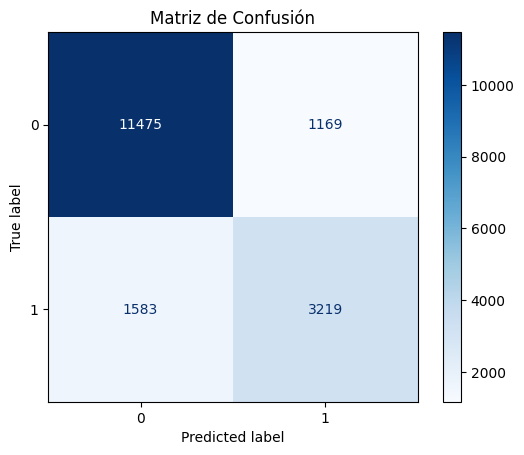

In [ ]:
cm = confusion_matrix(y_test, y_predict)

# 3. Mostrarla de forma visual y bonita
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_lgb.classes_)
disp.plot(cmap='Blues')

plt.title(f'Matriz de Confusión')
plt.show()

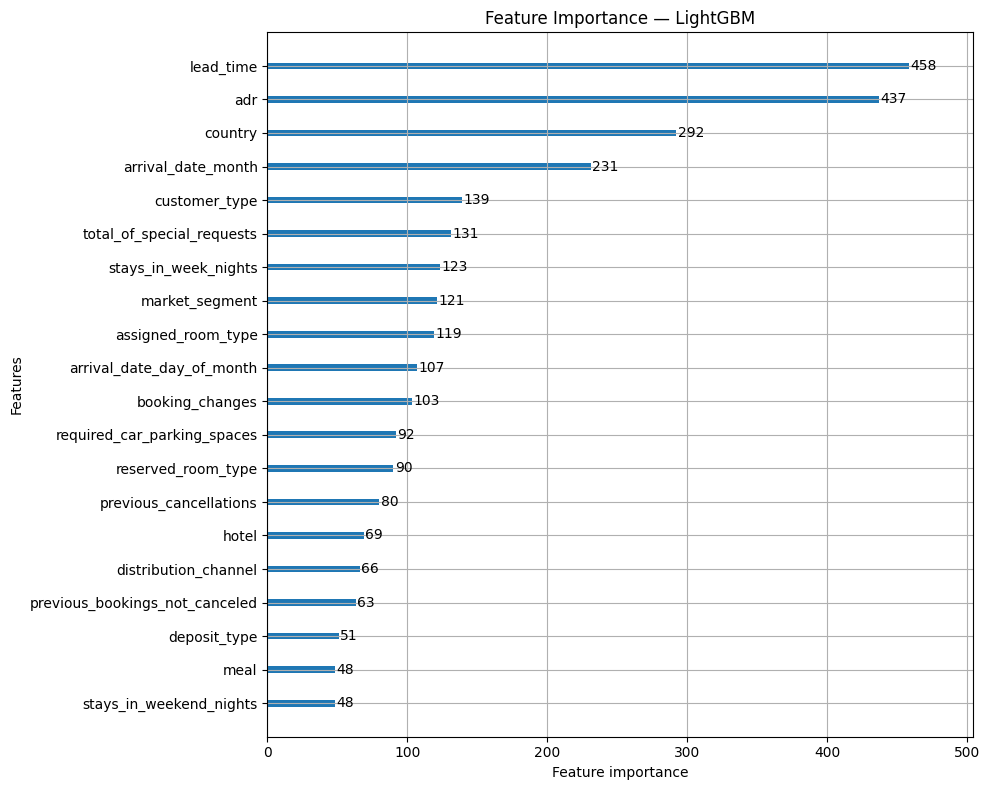

In [ ]:
# Importancia de features del mejor modelo LightGBM
lgb.plot_importance(model_lgb, figsize=(10, 8), title='Feature Importance — LightGBM', max_num_features=20)
plt.tight_layout()
plt.show()

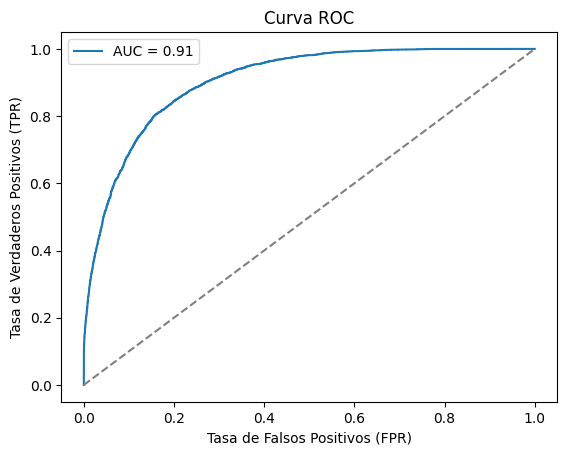

In [ ]:
# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_predict_proba[:, 1])
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend()
plt.show()